In [2]:
GPT_CONFIG_124M={
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads" : 12,
    "n_layers": 12, # num of transformer blocks in the model
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [3]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb=nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb=nn.Embedding(cfg["context_length"],cfg["emb_dim"])
        self.drop_emb=nn.Dropout(cfg["drop_rate"])
        self.trf_blocks=nn.Sequential(      # transformer blocks
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"]) ]
        )
        self.final_norm=DummyLayerNorm(cfg["emb_dim"])
        self.out_head=nn.Linear(
            cfg["emb_dim"],cfg["vocab_size"],bias=False
        )

    def forward(self,in_idx):
        batch_size,seq_len=in_idx.shape
        tok_embeds=self.tok_emb(in_idx)
        pos_embeds=self.pos_emb(
            torch.arange(seq_len,device=in_idx.device)
        )
        x=tok_embeds+pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()

    def forward(self,x):
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()

    def forward(self,x):
        return x

In [4]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")
batch=[]
txt1="Every effort moves you"
txt2="Every day holds a"
print(tokenizer.encode(txt1))
print(tokenizer.encode(txt2))
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
print(batch)
batch=torch.stack(batch,dim=0)
print(batch)

[6109, 3626, 6100, 345]
[6109, 1110, 6622, 257]
[tensor([6109, 3626, 6100,  345]), tensor([6109, 1110, 6622,  257])]
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [5]:
torch.manual_seed(123)
model=DummyGPTModel(GPT_CONFIG_124M)
logits=model(batch)
print("Output shape", logits.shape)
print( logits)

Output shape torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


In [6]:
torch.manual_seed(123)
batch_example=torch.randn(2,5)
print(batch)
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
out=layer(batch_example)
print(out)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [7]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [8]:
out_norm=(out-mean)/torch.sqrt(var)
mean=out_norm.mean(dim=-1,keepdim=True)
var=out_norm.var(dim=-1,keepdim=True)
print("Normalized layer outputs:\n", out_norm)
print("Mean:\n", mean)
print("Variance:\n", var)

Normalized layer outputs:
 tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
Mean:
 tensor([[-5.9605e-08],
        [ 1.9868e-08]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [9]:
class LayerNorm(nn.Module):
    def __init__(self,emb_dim):
        super().__init__()
        self.eps=1e-5
        self.scale=nn.Parameter(torch.ones(emb_dim))
        self.shift=nn.Parameter(torch.zeros(emb_dim))

    def forward(self,x):
        mean=x.mean(dim=-1,keepdim=True)
        var=x.var(dim=-1,keepdim=True,unbiased=False)
        norm_x=(x-mean)/torch.sqrt(var+self.eps)
        return self.scale* norm_x + self.shift

In [10]:
ln=LayerNorm(5)
out_ln=ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [11]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return x* 0.5 * (1+ torch.tanh(
            torch.sqrt(torch.tensor(2.0/torch.pi)) * (x+0.044715 * torch.pow(x, 3))
        ))

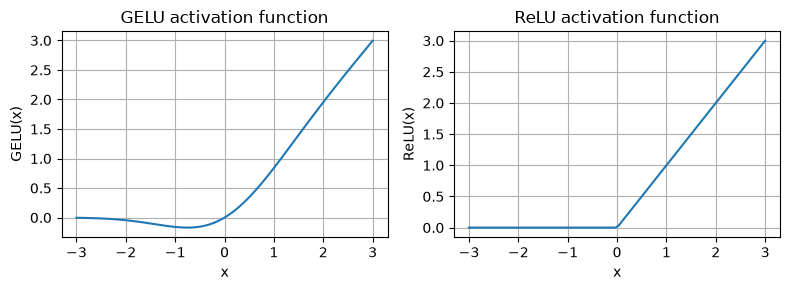

In [12]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
    plt.subplot(1, 2, i)
    plt.plot(x, y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)
    plt.tight_layout()
plt.show()

In [13]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers=nn.Sequential(
            nn.Linear(cfg["emb_dim"],4*cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"],cfg["emb_dim"]),
        )

    def forward(self,x):
        return self.layers(x)

In [14]:
ffn=FeedForward(GPT_CONFIG_124M)
x=torch.rand(2,3,768)
out=ffn(x)
print(out.shape)

torch.Size([2, 3, 768])


In [15]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self,layer_sizes,use_shortcut):
        super().__init__()
        self.use_shortcut=use_shortcut
        self.layers=nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]), GELU()),
        ])

    def forward(self,x):
        for layer in self.layers:
            layer_output=layer(x)
            if self.use_shortcut and layer_output.shape==x.shape:
                x= x+layer_output
            else:
                x=layer_output
        return x

In [16]:
layers_sizes=[3,3,3,3,3,1]
sample_input=torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123)
model_without_shortcut=ExampleDeepNeuralNetwork(layers_sizes,False)
torch.manual_seed(123)
model_with_shortcut=ExampleDeepNeuralNetwork(layers_sizes,True)
def print_gradients(model, x):
    output = model(x)
    target = torch.tensor([[0.]])
    loss = nn.MSELoss()
    loss = loss(output, target)
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


In [17]:
print_gradients(model_without_shortcut,sample_input)
print()
print_gradients(model_with_shortcut,sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031

layers.0.0.weight has gradient mean of 0.22169791162014008
layers.1.0.weight has gradient mean of 0.20694105327129364
layers.2.0.weight has gradient mean of 0.32896995544433594
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258540630340576


In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads==0), "d_out must be divisible by num_heads"

        self.d_out=d_out
        self.num_heads=num_heads
        self.head_dim=d_out//num_heads
        self.W_query=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.out_proj=nn.Linear(d_out,d_out)
        self.dropout=nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length,context_length),diagonal=1)
        )

    def forward(self,x):
        b,num_tokens,d_in=x.shape
        keys=self.W_key(x)
        queries=self.W_query(x)
        values=self.W_value(x)

        keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
        queries=queries.view(b,num_tokens,self.num_heads,self.head_dim)
        values=values.view(b,num_tokens,self.num_heads,self.head_dim)

        keys=keys.transpose(1,2)
        queries=queries.transpose(1,2)
        values=values.transpose(1,2)

        attn_scores=queries @ keys.transpose(2,3)
        mask_bool=self.mask.bool()[:num_tokens,:num_tokens]

        attn_scores.masked_fill_(mask_bool,-torch.inf)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec=(attn_weights @ values).transpose(1,2)

        context_vec=context_vec.contiguous().view(b,num_tokens,self.d_out)
        context_vec=self.out_proj(context_vec)
        return context_vec

In [19]:
class TransformerBlock(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.att=MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff=FeedForward(cfg)
        self.norm1=LayerNorm(cfg["emb_dim"])
        self.norm2=LayerNorm(cfg["emb_dim"])
        self.drop_shortcut=nn.Dropout(cfg["drop_rate"])

    def forward(self,x):
        shortcut=x      # shortcut for the attention block
        x=self.norm1(x)
        x=self.att(x)
        x=self.drop_shortcut(x)
        x=x+shortcut

        shortcut=x      # shortcut for feed forward block
        x=self.norm2(x)
        x=self.ff(x)
        x=self.drop_shortcut(x)
        x=x+shortcut
        return x

In [20]:
torch.manual_seed(123)
x= torch.rand(2,4,768)
block=TransformerBlock(GPT_CONFIG_124M)
output=block(x)
print("Input shape:", x.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])


In [21]:
class GPTModel(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb=nn.Embedding(cfg["vocab_size"] ,cfg["emb_dim"])
        self.pos_emb=nn.Embedding(cfg["context_length"] , cfg["emb_dim"])
        self.drop_emb=nn.Dropout(cfg["drop_rate"])

        self.trf_blocks=nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm=LayerNorm(cfg["emb_dim"])
        self.out_head=nn.Linear(cfg["emb_dim"],cfg["vocab_size"],bias=False)

    def forward(self,in_idx):
        batch_size,seq_len=in_idx.shape
        tok_embeds=self.tok_emb(in_idx)

        pos_embeds=self.pos_emb(
            torch.arange(seq_len,device=in_idx.device)
        )
        x=tok_embeds+pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

In [22]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [23]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")

Total number of parameters: 163,009,536


In [24]:
def generate_text_simple(model,idx,max_new_tokens,context_size):
    for _ in range(max_new_tokens):
        idx_cond=idx[:, -context_size:]
        with torch.no_grad():
            logits=model(idx_cond)

        logits=logits[:,-1,:]
        probas=torch.softmax(logits,dim=-1)
        idx_next=torch.argmax(probas,dim=-1,keepdim=True)
        idx=torch.cat((idx,idx_next),dim=1)
    return idx

In [25]:
start_context="I want to go"
encoded=tokenizer.encode(start_context)
print("encoded:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

encoded: [40, 765, 284, 467]
encoded_tensor.shape: torch.Size([1, 4])


In [26]:
model.eval()
out=generate_text_simple(model=model,idx=encoded_tensor,max_new_tokens=10,context_size=GPT_CONFIG_124M["context_length"])
print("Output ", out)
print("len ",len(out[0]))

Output  tensor([[   40,   765,   284,   467, 11313, 20351, 23482, 20363, 29179, 32885,
         46463,  8712, 35564, 18081]])
len  14


In [27]:
decoded=tokenizer.decode(out.squeeze(0).tolist())
print(decoded)

I want to go interrupt yoga whereby selfish conquestourage Wilkinson replied speedyHealth
